In [1]:
from datetime import datetime, UTC
from urllib.parse import urlencode
from urllib.request import urlopen
from urllib.error import HTTPError, URLError
import json

BASE_URL = "https://api.kraken.com"


def to_datetime(timestamp: int) -> str:
    return datetime.fromtimestamp(timestamp, UTC).strftime(
        "%Y-%m-%d %H:%M:%S UTC"
    )


def get_ohlc(pair="BTC/USD", interval=1440, since=None):
    """
    Fetch OHLC candles from Kraken.

    Intervals:
        1      = 1 minute
        5      = 5 minutes
        15     = 15 minutes
        30     = 30 minutes
        60     = 1 hour
        240    = 4 hours
        1440   = 1 day
        10080  = 1 week
        21600  = 15 days
    """

    params = {
        "pair": pair,
        "interval": interval,
    }

    if since is not None:
        params["since"] = since

    url = f"{BASE_URL}/0/public/OHLC?{urlencode(params)}"

    try:
        with urlopen(url) as response:
            payload = json.load(response)

        if payload["error"]:
            raise RuntimeError(payload["error"])

        result = payload["result"]

        # Pair key is dynamic
        pair_key = next(k for k in result.keys() if k != "last")

        candles = []

        for candle in result[pair_key]:
            candles.append({
                "timestamp": candle[0],
                "datetime": to_datetime(candle[0]),
                "open": float(candle[1]),
                "high": float(candle[2]),
                "low": float(candle[3]),
                "close": float(candle[4]),
                "vwap": float(candle[5]),
                "volume": float(candle[6]),
                "trades": int(candle[7]),
            })

        return candles

    except HTTPError as e:
        raise RuntimeError(f"HTTP error: {e.code}") from e

    except URLError as e:
        raise RuntimeError(f"Connection error: {e.reason}") from e


if __name__ == "__main__":
    daily_btc = get_ohlc(
        pair="BTC/USD",
        interval=1440,   # daily candles
    )

    data = json.dumps(daily_btc, indent=2)

In [2]:
import pandas as pd

# create dataframe
df = pd.DataFrame(json.loads(data))

# convert datetime column to pandas datetime
df["datetime"] = pd.to_datetime(df["datetime"])

print(df.head())

    timestamp                  datetime     open     high      low    close  \
0  1719446400 2024-06-27 00:00:00+00:00  60815.2  62297.8  60580.7  61617.1   
1  1719532800 2024-06-28 00:00:00+00:00  61617.1  62100.0  59942.7  60319.6   
2  1719619200 2024-06-29 00:00:00+00:00  60319.6  61102.1  60307.7  60860.0   
3  1719705600 2024-06-30 00:00:00+00:00  60860.0  62916.3  60660.7  62680.3   
4  1719792000 2024-07-01 00:00:00+00:00  62680.4  63798.9  62489.9  62858.5   

      vwap       volume  trades  
0  61491.3   878.315496   20197  
1  60940.8   880.356744   21465  
2  60859.3   495.324791   11596  
3  61800.8   819.171369   15253  
4  63155.0  1408.611072   23148  


In [3]:
df.drop(["timestamp", "vwap", "trades"], axis = 1, inplace = True)

df.head()

,datetime,open,high,low,close,volume
0,2024-06-27 00:00:00+00:00,60815.2,62297.8,60580.7,61617.1,878.315496
1,2024-06-28 00:00:00+00:00,61617.1,62100.0,59942.7,60319.6,880.356744
2,2024-06-29 00:00:00+00:00,60319.6,61102.1,60307.7,60860.0,495.324791
3,2024-06-30 00:00:00+00:00,60860.0,62916.3,60660.7,62680.3,819.171369
4,2024-07-01 00:00:00+00:00,62680.4,63798.9,62489.9,62858.5,1408.611072


In [4]:
df_filtered = df[
    (df["datetime"] >= "2025-01-01") &
    (df["datetime"] <= "2026-04-30")
].reset_index(drop=True)

df_filtered

,datetime,open,high,low,close,volume
0,2025-01-01 00:00:00+00:00,93370.8,94888.0,92588.1,94380.8,576.162219
1,2025-01-02 00:00:00+00:00,94380.9,97719.9,94167.2,96805.2,1727.878345
2,2025-01-03 00:00:00+00:00,96805.3,98888.0,96034.1,98111.1,1520.228296
3,2025-01-04 00:00:00+00:00,98111.1,98714.8,97548.4,98208.9,630.752662
4,2025-01-05 00:00:00+00:00,98208.9,98750.0,97250.0,98306.2,437.304342
...,...,...,...,...,...,...
480,2026-04-26 00:00:00+00:00,77648.5,78964.8,77356.2,78653.8,726.374952
481,2026-04-27 00:00:00+00:00,78653.8,79481.2,76480.4,77374.7,2180.499163
482,2026-04-28 00:00:00+00:00,77374.7,77799.0,75652.1,76331.9,1632.888391
483,2026-04-29 00:00:00+00:00,76331.9,77888.0,74940.0,75750.3,1865.527154


In [5]:
df = df_filtered.copy()

df["datetime"] = pd.to_datetime(df["datetime"])

df = df.sort_values("datetime").reset_index(drop=True)

In [6]:
df["candle_body"] = df["close"] - df["open"]

In [7]:
df["ret1"] = df["close"].pct_change(1)
df["ret3"] = df["close"].pct_change(3)
df["ret7"] = df["close"].pct_change(7)

In [8]:
df["breakout_20"] = (
    df["close"] /
    df["high"].rolling(20).max()
)

df["breakdown_20"] = (
    df["close"] /
    df["low"].rolling(20).min()
)

In [9]:
from ta.momentum import RSIIndicator
from ta.trend import EMAIndicator

df["rsi"] = RSIIndicator(
    close=df["close"],
    window=14
).rsi()

In [10]:
df["ema20"] = EMAIndicator(
    close=df["close"],
    window=20
).ema_indicator()

In [11]:
df["ema20_dist"] = (
    (df["close"] - df["ema20"]) / df["ema20"]
)

In [12]:
df["future_return"] = (
    (df["close"].shift(-1) - df["close"]) / df["close"]
)

df["target"] = (
    df["candle_body"] > 0
).astype(int)

In [13]:
df["target"] = df["target"].shift(-1)
df = df.dropna().reset_index(drop=True)
df

,datetime,open,high,low,close,volume,candle_body,ret1,ret3,ret7,breakout_20,breakdown_20,rsi,ema20,ema20_dist,future_return,target
0,2025-01-20 00:00:00+00:00,101191.0,109112.0,99500.0,102162.8,6144.710114,971.8,0.009603,-0.018513,0.081235,0.936311,1.147822,62.042960,98494.274386,0.037246,0.039153,1.0
1,2025-01-21 00:00:00+00:00,102142.1,107200.0,100114.2,106162.8,2766.178680,4020.7,0.039153,0.017060,0.099448,0.972971,1.192763,68.920871,99224.610158,0.069924,-0.023683,0.0
2,2025-01-22 00:00:00+00:00,106162.8,106293.4,103271.3,103648.5,1391.420726,-2514.3,-0.023683,0.024285,0.031365,0.949928,1.164514,61.390642,99645.933001,0.040168,0.002621,1.0
3,2025-01-23 00:00:00+00:00,103648.6,106833.2,101281.7,103920.2,4692.190785,271.6,0.002621,0.017202,0.039444,0.952418,1.167567,61.875395,100053.006048,0.038651,0.008855,1.0
4,2025-01-24 00:00:00+00:00,103920.2,107080.6,102800.0,104840.4,1795.722536,920.2,0.008855,-0.012456,0.007211,0.960851,1.177905,63.544809,100508.948329,0.043095,-0.001290,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
460,2026-04-25 00:00:00+00:00,77455.0,77876.3,77145.3,77648.5,464.668651,193.5,0.002498,-0.007103,0.025350,0.976825,1.146359,62.752690,74746.713617,0.038822,0.012947,1.0
461,2026-04-26 00:00:00+00:00,77648.5,78964.8,77356.2,78653.8,726.374952,1005.3,0.012947,0.004729,0.065371,0.989472,1.161201,65.148517,75118.817082,0.047059,-0.016262,0.0
462,2026-04-27 00:00:00+00:00,78653.8,79481.2,76480.4,77374.7,2180.499163,-1279.1,-0.016262,-0.001037,0.020124,0.973381,1.098057,59.871659,75333.663074,0.027093,-0.013477,0.0
463,2026-04-28 00:00:00+00:00,77374.7,77799.0,75652.1,76331.9,1632.888391,-1042.8,-0.013477,-0.016956,-0.000262,0.960262,1.083258,55.896652,75428.733258,0.011974,-0.007619,0.0


In [14]:
features_to_lag = [
    "open",
    "high",
    "low",
    "close",
    "candle_body",
    "volume",
    "rsi",
    "ema20_dist",
]

In [15]:
lags = 5

for feature in features_to_lag:
    
    for lag in range(1, lags + 1):
        
        df[f"{feature}_lag{lag}"] = (
            df[feature].shift(lag)
        )

In [16]:
df = df.dropna().reset_index(drop=True)

In [17]:
test_df = df[
    (df["datetime"] >= "2026-01-01") &
    (df["datetime"] <= "2026-04-30")
].reset_index(drop=True)

test_df

,datetime,open,high,low,close,volume,candle_body,ret1,ret3,ret7,...,rsi_lag1,rsi_lag2,rsi_lag3,rsi_lag4,rsi_lag5,ema20_dist_lag1,ema20_dist_lag2,ema20_dist_lag3,ema20_dist_lag4,ema20_dist_lag5
0,2026-01-01 00:00:00+00:00,87500.2,88779.3,87400.0,88731.8,1157.563409,1231.6,0.014077,0.018324,0.017590,...,44.596457,47.768020,42.427261,44.841024,44.634550,-0.008567,0.000749,-0.013514,-0.006796,-0.008079
1,2026-01-02 00:00:00+00:00,88730.0,90900.0,88273.3,89934.0,1901.882681,1204.0,0.013549,0.017331,0.030129,...,49.525758,44.596457,47.768020,42.427261,44.841024,0.004873,-0.008567,0.000749,-0.013514,-0.006796
2,2026-01-03 00:00:00+00:00,89934.0,90677.5,89300.0,90590.1,1113.010386,656.1,0.007295,0.035314,0.031747,...,53.842413,49.525758,44.596457,47.768020,42.427261,0.016698,0.004873,-0.008567,0.000749,-0.013514
3,2026-01-04 00:00:00+00:00,90590.1,91768.3,90590.0,91507.0,843.083779,916.9,0.010121,0.031276,0.041589,...,56.051436,53.842413,49.525758,44.596457,47.768020,0.021768,0.016698,0.004873,-0.008567,0.000749
4,2026-01-05 00:00:00+00:00,91507.0,94783.9,91489.5,93866.9,2070.652941,2359.9,0.025789,0.043731,0.077257,...,59.004227,56.051436,53.842413,49.525758,44.596457,0.028963,0.021768,0.016698,0.004873,-0.008567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,2026-04-25 00:00:00+00:00,77455.0,77876.3,77145.3,77648.5,464.668651,193.5,0.002498,-0.007103,0.025350,...,62.289351,65.530718,65.369968,61.489696,60.368487,0.040485,0.056116,0.061312,0.042907,0.040729
115,2026-04-26 00:00:00+00:00,77648.5,78964.8,77356.2,78653.8,726.374952,1005.3,0.012947,0.004729,0.065371,...,62.752690,62.289351,65.530718,65.369968,61.489696,0.038822,0.040485,0.056116,0.061312,0.042907
116,2026-04-27 00:00:00+00:00,78653.8,79481.2,76480.4,77374.7,2180.499163,-1279.1,-0.016262,-0.001037,0.020124,...,65.148517,62.752690,62.289351,65.530718,65.369968,0.047059,0.038822,0.040485,0.056116,0.061312
117,2026-04-28 00:00:00+00:00,77374.7,77799.0,75652.1,76331.9,1632.888391,-1042.8,-0.013477,-0.016956,-0.000262,...,59.871659,65.148517,62.752690,62.289351,65.530718,0.027093,0.047059,0.038822,0.040485,0.056116


In [18]:
test_df.columns

Index(['datetime', 'open', 'high', 'low', 'close', 'volume', 'candle_body',
       'ret1', 'ret3', 'ret7', 'breakout_20', 'breakdown_20', 'rsi', 'ema20',
       'ema20_dist', 'future_return', 'target', 'open_lag1', 'open_lag2',
       'open_lag3', 'open_lag4', 'open_lag5', 'high_lag1', 'high_lag2',
       'high_lag3', 'high_lag4', 'high_lag5', 'low_lag1', 'low_lag2',
       'low_lag3', 'low_lag4', 'low_lag5', 'close_lag1', 'close_lag2',
       'close_lag3', 'close_lag4', 'close_lag5', 'candle_body_lag1',
       'candle_body_lag2', 'candle_body_lag3', 'candle_body_lag4',
       'candle_body_lag5', 'volume_lag1', 'volume_lag2', 'volume_lag3',
       'volume_lag4', 'volume_lag5', 'rsi_lag1', 'rsi_lag2', 'rsi_lag3',
       'rsi_lag4', 'rsi_lag5', 'ema20_dist_lag1', 'ema20_dist_lag2',
       'ema20_dist_lag3', 'ema20_dist_lag4', 'ema20_dist_lag5'],
      dtype='str')

In [ ]:
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate

llm = ChatOllama(
    #model="phi4-mini-reasoning:3.8b",
    model = "llama3.1:8b",
    temperature=0
)

TA_SYSTEM_PROMPT = """
You are a Financial Technical Analyst.
You are Analyzing Bitcoin Daily Prices.
Your role is, given a set of technical and price action indicators,
to analyze the overall context, perform an analisys, and return a complete Technical Analysis of the Given Indicators and Price Action.
"""

TA_PROMPT = """
You are given the following Technical and Price Action Indicators.
First, here are the Previous 5 Day Open High Low Close, with respective current readings.
Previous 5 Day Open Prices: {open_lag5}, {open_lag4}, {open_lag3}, {open_lag2}, {open_lag1}
Here's the Current Open Price: {open}
Previous 5 Day High Prices: {high_lag5}, {high_lag4}, {high_lag3}, {high_lag2}, {high_lag1}
Here's the Current High Price: {high}
Previous 5 Day Low Prices: {low_lag5}, {low_lag4}, {low_lag3}, {low_lag2}, {low_lag1}
Here's the Current Low Price: {low}
Previous 5 Day Close Prices: {close_lag5}, {close_lag4}, {close_lag3}, {close_lag2}, {close_lag1}
Here's the Current Close Price: {close}

Then, you are given the 3 day and 7 day returns:
3 Day Returns: {ret3}
7 Day Returns: {ret7}

Then I want you to analyze the volumes.
Previous 5 Day Volumes: {volume_lag5}, {volume_lag4}, {volume_lag3}, {volume_lag2}, {volume_lag1}
Here's the Current Volumes: {volume}

Then I want you to analize the previous 5 day trend of RSI readings and then the current RSI reading.
Previous 5 Day RSI: {rsi_lag5}, {rsi_lag4}, {rsi_lag3}, {rsi_lag2}, {rsi_lag1}
Here's the current RSI reading: {rsi}

Now it's time for the distance of the close price to the EMA(20)
Previous 5 Day EMA Distances: {ema20_dist_lag5}, {ema20_dist_lag4}, {ema20_dist_lag3}, {ema20_dist_lag2}, {ema20_dist_lag1}
Here's the current EMA Distance from the Close Price {ema20_dist}

INSTRUCTIONS:

For Open High Low Close Prices, analyze carefully whether the price is compressing or expanding, where when compressing means that volatility is low and viceversa,
when the price is expanding means that volatility is increasing.
Also, look for any consecutive bullish or bearish candles, as they highlight momentum.
Mixed Candles suggest a neutral signal.

For the RSI, analyze carefully the overall trend and the current reading.
A sideways trend for the RSI indicates a neutral signal.
An uptrend for the RSI indicates a bullish signal if the values are below the 70 mark, if values are uptrending above the 70 mark it's a bearish signal.
A downtrend for the RSI indicates a bearish signal if the values are above the 30 mark, if values are downtrending below the 30 mark it's a bullish signal.

For the Distance from the EMA, closer values to 0 indicate a neutral signal.
Values above the 0 indicate a bullish signal, but only if they are uptrending, while if they are downtrending above the 0 it's a bearish signal.
Values below the 0 indicate a bearish signal, but only if they are downtrending, while if they are uptrending below the 0 it's a bullish signal.

For the Volumes, use them to understand the overall trading pressure where higher volumes confirm increasing volatility.

You can use the 3 Day Returns as short term momentum indicator, and the 7 Day Returns as medium term momentum indicator.
When the 7 Day Returns are negative but the 3 Day Returns are positive, that might mean a bullish reversal, hence, it's a Bullish Signal.
When the 7 Day Returns are positive but the 3 Day Returns are negative, that might mean a bearish reversal, hence, it's a Bearish Signal.
If the 7 Day and 3 Day returns are both positive, it's a bullish signal, while if they are both negative, it's a bearish signal.

DELIVERY:
Deliver a Complete Technical Analysis.
Only use "'" when formatting the output and not elsewhere.
Do not give trading advice, only perform a neutral Technical Analysis.
"""

rsi = test_df.loc[0, "rsi"]
rsi_lag5 = test_df.loc[0, "rsi_lag5"]
rsi_lag4 = test_df.loc[0, "rsi_lag4"]
rsi_lag3 = test_df.loc[0, "rsi_lag3"]
rsi_lag2 = test_df.loc[0, "rsi_lag2"]
rsi_lag1 = test_df.loc[0, "rsi_lag1"]

ema20_dist = test_df.loc[0, "ema20_dist"]
ema20_dist_lag5 = test_df.loc[0, "ema20_dist_lag5"]
ema20_dist_lag4 = test_df.loc[0, "ema20_dist_lag4"]
ema20_dist_lag3 = test_df.loc[0, "ema20_dist_lag3"]
ema20_dist_lag2 = test_df.loc[0, "ema20_dist_lag2"]
ema20_dist_lag1 = test_df.loc[0, "ema20_dist_lag1"]

open_ = test_df.loc[0, "open"]
open_lag5 = test_df.loc[0, "open_lag5"]
open_lag4 = test_df.loc[0, "open_lag4"]
open_lag3 = test_df.loc[0, "open_lag3"]
open_lag2 = test_df.loc[0, "open_lag2"]
open_lag1 = test_df.loc[0, "open_lag1"]

high = test_df.loc[0, "high"]
high_lag5 = test_df.loc[0, "high_lag5"]
high_lag4 = test_df.loc[0, "high_lag4"]
high_lag3 = test_df.loc[0, "high_lag3"]
high_lag2 = test_df.loc[0, "high_lag2"]
high_lag1 = test_df.loc[0, "high_lag1"]

low = test_df.loc[0, "low"]
low_lag5 = test_df.loc[0, "low_lag5"]
low_lag4 = test_df.loc[0, "low_lag4"]
low_lag3 = test_df.loc[0, "low_lag3"]
low_lag2 = test_df.loc[0, "low_lag2"]
low_lag1 = test_df.loc[0, "low_lag1"]

close = test_df.loc[0, "close"]
close_lag5 = test_df.loc[0, "close_lag5"]
close_lag4 = test_df.loc[0, "close_lag4"]
close_lag3 = test_df.loc[0, "close_lag3"]
close_lag2 = test_df.loc[0, "close_lag2"]
close_lag1 = test_df.loc[0, "close_lag1"]

volume = test_df.loc[0, "volume"]
volume_lag5 = test_df.loc[0, "volume_lag5"]
volume_lag4 = test_df.loc[0, "volume_lag4"]
volume_lag3 = test_df.loc[0, "volume_lag3"]
volume_lag2 = test_df.loc[0, "volume_lag2"]
volume_lag1 = test_df.loc[0, "volume_lag1"]

ret3 = test_df.loc[0, "ret3"]
ret7 = test_df.loc[0, "ret7"]

prompt = ChatPromptTemplate.from_messages([
    ("system", TA_SYSTEM_PROMPT),
    ("human", TA_PROMPT)
])

TAchain = prompt | llm

TAresponse = TAchain.invoke({
    "rsi": rsi,
    "rsi_lag5": rsi_lag5,
    "rsi_lag4": rsi_lag4,
    "rsi_lag3": rsi_lag3,
    "rsi_lag2": rsi_lag2,
    "rsi_lag1": rsi_lag1,
    "ema20_dist": ema20_dist,
    "ema20_dist_lag5": ema20_dist_lag5,
    "ema20_dist_lag4": ema20_dist_lag4,
    "ema20_dist_lag3": ema20_dist_lag3,
    "ema20_dist_lag2": ema20_dist_lag2,
    "ema20_dist_lag1": ema20_dist_lag1,
    "open": open_,
    "open_lag5": open_lag5,
    "open_lag4": open_lag4,
    "open_lag3": open_lag3,
    "open_lag2": open_lag2,
    "open_lag1": open_lag1,
    "high": high,
    "high_lag5": high_lag5,
    "high_lag4": high_lag4,
    "high_lag3": high_lag3,
    "high_lag2": high_lag2,
    "high_lag1": high_lag1,
    "low": low,
    "low_lag5": low_lag5,
    "low_lag4": low_lag4,
    "low_lag3": low_lag3,
    "low_lag2": low_lag2,
    "low_lag1": low_lag1,
    "close": close,
    "close_lag5": close_lag5,
    "close_lag4": close_lag4,
    "close_lag3": close_lag3,
    "close_lag2": close_lag2,
    "close_lag1": close_lag1,
    "volume": volume,
    "volume_lag5": volume_lag5,
    "volume_lag4": volume_lag4,
    "volume_lag3": volume_lag3,
    "volume_lag2": volume_lag2,
    "volume_lag1": volume_lag1,
    "ret3": ret3,
    "ret7": ret7
})

print(TAresponse.content)

**Technical Analysis Report**

**Price Action Indicators: Open High Low Close Prices**

The price action indicators suggest that the market is currently in an expansion phase. The current high price of 88779.3 is higher than the previous highs, while the current low price of 87400.0 is lower than the previous lows. This indicates increasing volatility.

There are no consecutive bullish or bearish candles, suggesting a neutral signal.

**Volume Analysis**

The volume has increased from 416.75 to 1157.56, indicating increasing trading pressure and confirming the expansion phase.

**RSI Trend Analysis**

The RSI trend is currently in an uptrend, with a reading of 49.53. However, this is above the 70 mark, which indicates a bearish signal.

Looking at the previous 5-day RSI readings, we can see that there was a downtrend from 44.63 to 42.43, followed by an uptrend to 47.77 and then another downtrend to 44.60. This suggests a neutral signal.

**Distance from EMA(20) Analysis**

The current 

In [20]:
from typing import Literal
from pydantic import BaseModel, Field

class MarketOutlook(BaseModel):
    outlook: Literal["bullish", "bearish", "neutral"] = Field(
        description="Expected market direction for the next trading day"
    )
    reasoning: str = Field(
        description="Complete Explanation of the analysis and reasoning behind it."
    )

In [21]:
llm = ChatOllama(
    model="phi4-mini-reasoning:3.8b",
    #model = "llama3.1:8b",
    temperature=0
)

structured_llm = llm.with_structured_output(MarketOutlook)

REASONING_SYSTEM_PROMPT = """
You are the head of a trading desk.
Your colleague has prepared for you a Technical Analysis Report About Bitcoin Daily Price Action and Indicators.
Your role is to Reason and think about the Technical Analysis report as you go through it and decide wheter to take a trade (Bullish or Bearish Signal) or Not (Neutral Signal).
"""

REASONING_PROMPT = """
Here's the technical analysis report:

{report}

Never Trade when volumes are low and when there is low volatility (Neutral Trading Signal).
When Indicators and Price Action are giving mixed signals, that's a Neutral Trading Signal.
If most Indicators and Price Action are giving Bullish Sentiment, then it's a Bullish Trading Signal.
If most Indicators and Price Action are giving Bearish Sentiment, then it's a Bearish Trading Signal.

DELIVERY:

Deliver a market outlook for the next trading day, which can be Bullish, Bearish, or Neutral.
Also Deliver a Complete Analysis which will contain the reasoning behind the Trading Signal.
Only use "'" when formatting the output and not elsewhere.
"""

prompt = ChatPromptTemplate.from_messages([
    ("system", REASONING_SYSTEM_PROMPT),
    ("human", REASONING_PROMPT)
])

REASONINGchain = prompt | structured_llm

response = REASONINGchain.invoke({
    "report": TAresponse.content,
})

print(response)

outlook='neutral' reasoning='The technical analysis report presents mixed signals. While price action indicators suggest an expansion phase with increasing volatility, key momentum indicators like RSI and distance from EMA(20) indicate bearish trends. Although there is a bullish signal from 3-day and 7-day returns, the overbought RSI level (above 70%) and non-uptrending EMA distance contribute to a more cautious outlook. The lack of consecutive bullish or bearish candles further supports a neutral stance. Additionally, the trading principle of avoiding low volumes and volatility aligns with a neutral recommendation.'


In [23]:
predictions = []
TAanalysis = []
REASONINGanalysis = []

for idx, row in test_df.iterrows():
    print(idx)
    TAresponse = TAchain.invoke({
        "rsi": row["rsi"],
        "rsi_lag5": row["rsi_lag5"],
        "rsi_lag4": row["rsi_lag4"],
        "rsi_lag3": row["rsi_lag3"],
        "rsi_lag2": row["rsi_lag2"],
        "rsi_lag1": row["rsi_lag1"],

        "ema20_dist": row["ema20_dist"],
        "ema20_dist_lag5": row["ema20_dist_lag5"],
        "ema20_dist_lag4": row["ema20_dist_lag4"],
        "ema20_dist_lag3": row["ema20_dist_lag3"],
        "ema20_dist_lag2": row["ema20_dist_lag2"],
        "ema20_dist_lag1": row["ema20_dist_lag1"],

        "open": row["open"],
        "open_lag5": row["open_lag5"],
        "open_lag4": row["open_lag4"],
        "open_lag3": row["open_lag3"],
        "open_lag2": row["open_lag2"],
        "open_lag1": row["open_lag1"],

        "high": row["high"],
        "high_lag5": row["high_lag5"],
        "high_lag4": row["high_lag4"],
        "high_lag3": row["high_lag3"],
        "high_lag2": row["high_lag2"],
        "high_lag1": row["high_lag1"],

        "low": row["low"],
        "low_lag5": row["low_lag5"],
        "low_lag4": row["low_lag4"],
        "low_lag3": row["low_lag3"],
        "low_lag2": row["low_lag2"],
        "low_lag1": row["low_lag1"],

        "close": row["close"],
        "close_lag5": row["close_lag5"],
        "close_lag4": row["close_lag4"],
        "close_lag3": row["close_lag3"],
        "close_lag2": row["close_lag2"],
        "close_lag1": row["close_lag1"],

        "volume": row["volume"],
        "volume_lag5": row["volume_lag5"],
        "volume_lag4": row["volume_lag4"],
        "volume_lag3": row["volume_lag3"],
        "volume_lag2": row["volume_lag2"],
        "volume_lag1": row["volume_lag1"],

        "ret3": row["ret3"],
        "ret7": row["ret7"]
    })

    REASONINGresponse = REASONINGchain.invoke({
    "report": TAresponse.content,
    })
    
    TAanalysis.append(TAresponse.content)
    REASONINGanalysis.append(REASONINGresponse.reasoning)
    predictions.append(REASONINGresponse.outlook)

test_df["prediction"] = predictions

position_map = {
    "bullish": 1,
    "bearish": -1,
    "neutral": 0
}

test_df["position"] = test_df["prediction"].map(position_map)

test_df["strategy_return"] = (
    test_df["position"] *
    test_df["future_return"]
)

test_df["strategy_equity"] = (
    1 + test_df["strategy_return"]
).cumprod()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118


In [24]:
test_df.to_csv("MultiAgentLLM_Results.csv")

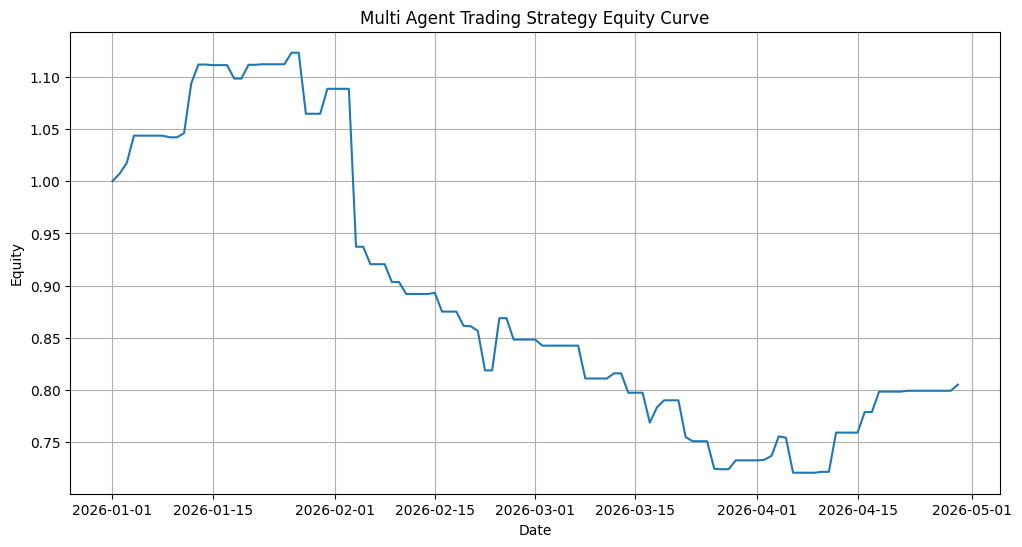

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    test_df["datetime"],
    test_df["strategy_equity"]
)

plt.title("Multi Agent Trading Strategy Equity Curve")
plt.xlabel("Date")
plt.ylabel("Equity")

plt.show()

In [1]:
import pandas as pd

In [3]:
test_df = pd.read_csv("MultiAgentLLM_Results.csv")

test_df

,Unnamed: 0,datetime,open,high,low,close,volume,candle_body,ret1,ret3,...,rsi_lag5,ema20_dist_lag1,ema20_dist_lag2,ema20_dist_lag3,ema20_dist_lag4,ema20_dist_lag5,prediction,position,strategy_return,strategy_equity
0,0,2026-01-01 00:00:00+00:00,87500.2,88779.3,87400.0,88731.8,1157.563409,1231.6,0.014077,0.018324,...,44.634550,-0.008567,0.000749,-0.013514,-0.006796,-0.008079,neutral,0,0.000000,1.000000
1,1,2026-01-02 00:00:00+00:00,88730.0,90900.0,88273.3,89934.0,1901.882681,1204.0,0.013549,0.017331,...,44.841024,0.004873,-0.008567,0.000749,-0.013514,-0.006796,bullish,1,0.007295,1.007295
2,2,2026-01-03 00:00:00+00:00,89934.0,90677.5,89300.0,90590.1,1113.010386,656.1,0.007295,0.035314,...,42.427261,0.016698,0.004873,-0.008567,0.000749,-0.013514,bullish,1,0.010121,1.017491
3,3,2026-01-04 00:00:00+00:00,90590.1,91768.3,90590.0,91507.0,843.083779,916.9,0.010121,0.031276,...,47.768020,0.021768,0.016698,0.004873,-0.008567,0.000749,bullish,1,0.025789,1.043731
4,4,2026-01-05 00:00:00+00:00,91507.0,94783.9,91489.5,93866.9,2070.652941,2359.9,0.025789,0.043731,...,44.596457,0.028963,0.021768,0.016698,0.004873,-0.008567,neutral,0,-0.000000,1.043731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,114,2026-04-25 00:00:00+00:00,77455.0,77876.3,77145.3,77648.5,464.668651,193.5,0.002498,-0.007103,...,60.368487,0.040485,0.056116,0.061312,0.042907,0.040729,neutral,0,0.000000,0.799131
115,115,2026-04-26 00:00:00+00:00,77648.5,78964.8,77356.2,78653.8,726.374952,1005.3,0.012947,0.004729,...,61.489696,0.038822,0.040485,0.056116,0.061312,0.042907,neutral,0,-0.000000,0.799131
116,116,2026-04-27 00:00:00+00:00,78653.8,79481.2,76480.4,77374.7,2180.499163,-1279.1,-0.016262,-0.001037,...,65.369968,0.047059,0.038822,0.040485,0.056116,0.061312,neutral,0,-0.000000,0.799131
117,117,2026-04-28 00:00:00+00:00,77374.7,77799.0,75652.1,76331.9,1632.888391,-1042.8,-0.013477,-0.016956,...,65.530718,0.027093,0.047059,0.038822,0.040485,0.056116,neutral,0,-0.000000,0.799131


In [4]:
# rolling maximum equity
test_df["equity_peak"] = (
    test_df["strategy_equity"].cummax()
)

# drawdown
test_df["drawdown"] = (
    test_df["strategy_equity"] /
    test_df["equity_peak"] - 1
)

# maximum drawdown
max_drawdown = test_df["drawdown"].min()

print("Max Drawdown:", max_drawdown)

Max Drawdown: -0.3584911731493309


In [5]:
# winning trades
gross_profit = test_df.loc[
    test_df["strategy_return"] > 0,
    "strategy_return"
].sum()

# losing trades
gross_loss = abs(
    test_df.loc[
        test_df["strategy_return"] < 0,
        "strategy_return"
    ].sum()
)

profit_factor = gross_profit / gross_loss

print("Profit Factor:", profit_factor)

Profit Factor: 0.6790648302857305
